In [9]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(threshold=np.inf)


In [10]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df['DATE']=pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)



DATE
1869-01-01    24.0
1869-01-02    24.0
1869-01-03    31.0
1869-01-04    35.5
1869-01-05    40.0
Name: Temp, dtype: float64


<Axes: xlabel='DATE'>

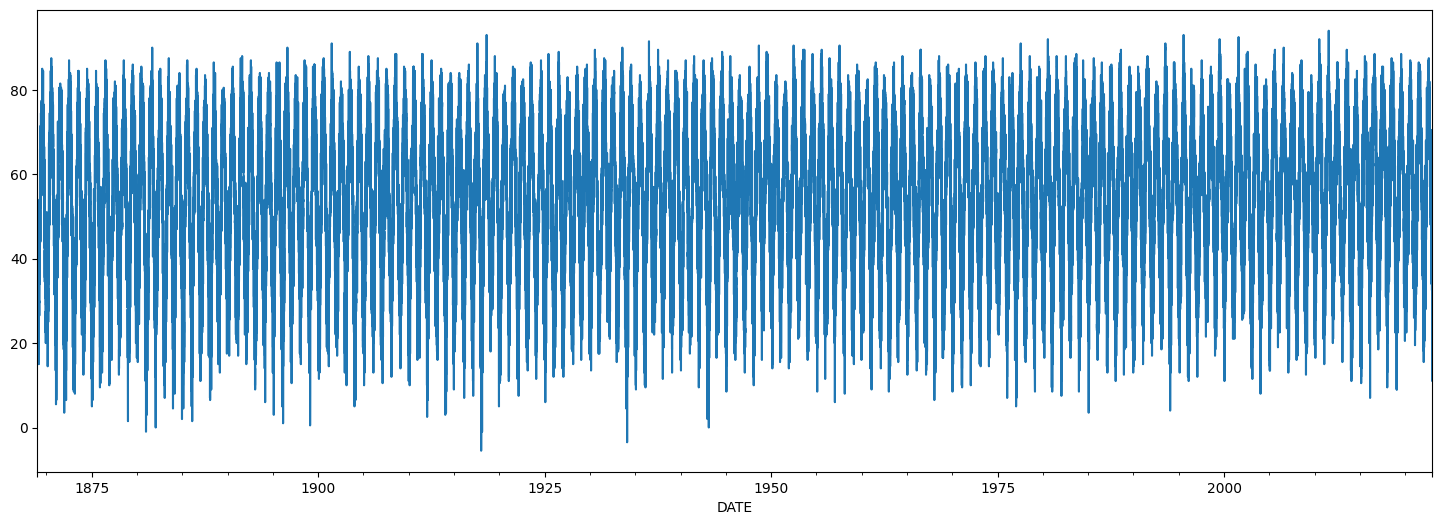

In [11]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df['Temp']
#print(temp.isna().sum())
temp = temp.ffill()
#print(temp.isna().sum())
print(temp.head())


temp.plot(figsize=(18, 6))



In [12]:
def seq2seq_data(df, window_size=60, horizon=30):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size-horizon):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=[[a] for a in df_as_np[i+window_size:i+window_size+horizon]]
        y.append(label)
    return np.array(X), np.array(y)

HORIZON=7
WINDOW_SIZE=30
X, y =seq2seq_data(temp, WINDOW_SIZE, HORIZON)
X.shape, y.shape


((56208, 30, 1), (56208, 7, 1))

In [13]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape
print(X_train[:5])

[[[24. ]
  [24. ]
  [31. ]
  [35.5]
  [40. ]
  [36. ]
  [41.5]
  [47. ]
  [43. ]
  [38.5]
  [31.5]
  [33. ]
  [33. ]
  [37. ]
  [40.5]
  [35. ]
  [32. ]
  [27.5]
  [30.5]
  [33.5]
  [35.5]
  [23. ]
  [29.5]
  [41.5]
  [30. ]
  [24.5]
  [31.5]
  [41. ]
  [39. ]
  [47.5]]

 [[24. ]
  [31. ]
  [35.5]
  [40. ]
  [36. ]
  [41.5]
  [47. ]
  [43. ]
  [38.5]
  [31.5]
  [33. ]
  [33. ]
  [37. ]
  [40.5]
  [35. ]
  [32. ]
  [27.5]
  [30.5]
  [33.5]
  [35.5]
  [23. ]
  [29.5]
  [41.5]
  [30. ]
  [24.5]
  [31.5]
  [41. ]
  [39. ]
  [47.5]
  [35.5]]

 [[31. ]
  [35.5]
  [40. ]
  [36. ]
  [41.5]
  [47. ]
  [43. ]
  [38.5]
  [31.5]
  [33. ]
  [33. ]
  [37. ]
  [40.5]
  [35. ]
  [32. ]
  [27.5]
  [30.5]
  [33.5]
  [35.5]
  [23. ]
  [29.5]
  [41.5]
  [30. ]
  [24.5]
  [31.5]
  [41. ]
  [39. ]
  [47.5]
  [35.5]
  [29. ]]

 [[35.5]
  [40. ]
  [36. ]
  [41.5]
  [47. ]
  [43. ]
  [38.5]
  [31.5]
  [33. ]
  [33. ]
  [37. ]
  [40.5]
  [35. ]
  [32. ]
  [27.5]
  [30.5]
  [33.5]
  [35.5]
  [23. ]
  [29.5]
  [4

In [14]:
from tensorflow.keras.models import Model              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [15]:
encoder_inputs=Input(shape=(WINDOW_SIZE, 1))
encoder=LSTM(128, return_state=True)
encoder_output, state_h, state_c=encoder(encoder_inputs)
encoder_states=[state_h, state_c]

In [16]:
decoder_inputs=RepeatVector(HORIZON)(encoder_output)
decoder_lstm=LSTM(128, return_sequences=True)
decoder_outputs=decoder_lstm(decoder_inputs, initial_state=encoder_states)

In [17]:
decoder_outputs=TimeDistributed(Dense(1))(decoder_outputs)

In [18]:
model2=Model(encoder_inputs, decoder_outputs)
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     66,560 │ input_layer[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 7, 128)    │          0 │ lstm[0][0]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 7, 128)    │    131,584 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 7, 1)      │        129 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cp=ModelCheckpoint('model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])


In [20]:
model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, callbacks=[cp])

Epoch 1/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 1400.2686 - root_mean_squared_error: 37.4202 - val_loss: 858.5994 - val_root_mean_squared_error: 29.3019
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 563.5795 - root_mean_squared_error: 23.7398 - val_loss: 381.5208 - val_root_mean_squared_error: 19.5326
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 250.7985 - root_mean_squared_error: 15.8366 - val_loss: 170.8023 - val_root_mean_squared_error: 13.0691
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - loss: 119.0833 - root_mean_squared_error: 10.9125 - val_loss: 91.4589 - val_root_mean_squared_error: 9.5634
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - loss: 73.7961 - root_mean_squared_error: 8.5905 - val_loss: 65.5677 - val_root_mean_squared_error: 8.0974
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - loss: 62.4253 - root_mean_squared_error: 7.9010 - val_loss: 60.0580 - val_root_mean_squared_error: 7.7497
E

In [21]:
from tensorflow.keras.models import load_model
model2=load_model('model2.keras')

In [22]:
last_window=temp.values[-WINDOW_SIZE:]
last_window=np.array([[[a] for a in last_window]])
future_30=model2.predict(last_window)
future_30=future_30.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


[40.42636  37.269653 36.040936 35.71031  35.690407 35.76121  35.846317]


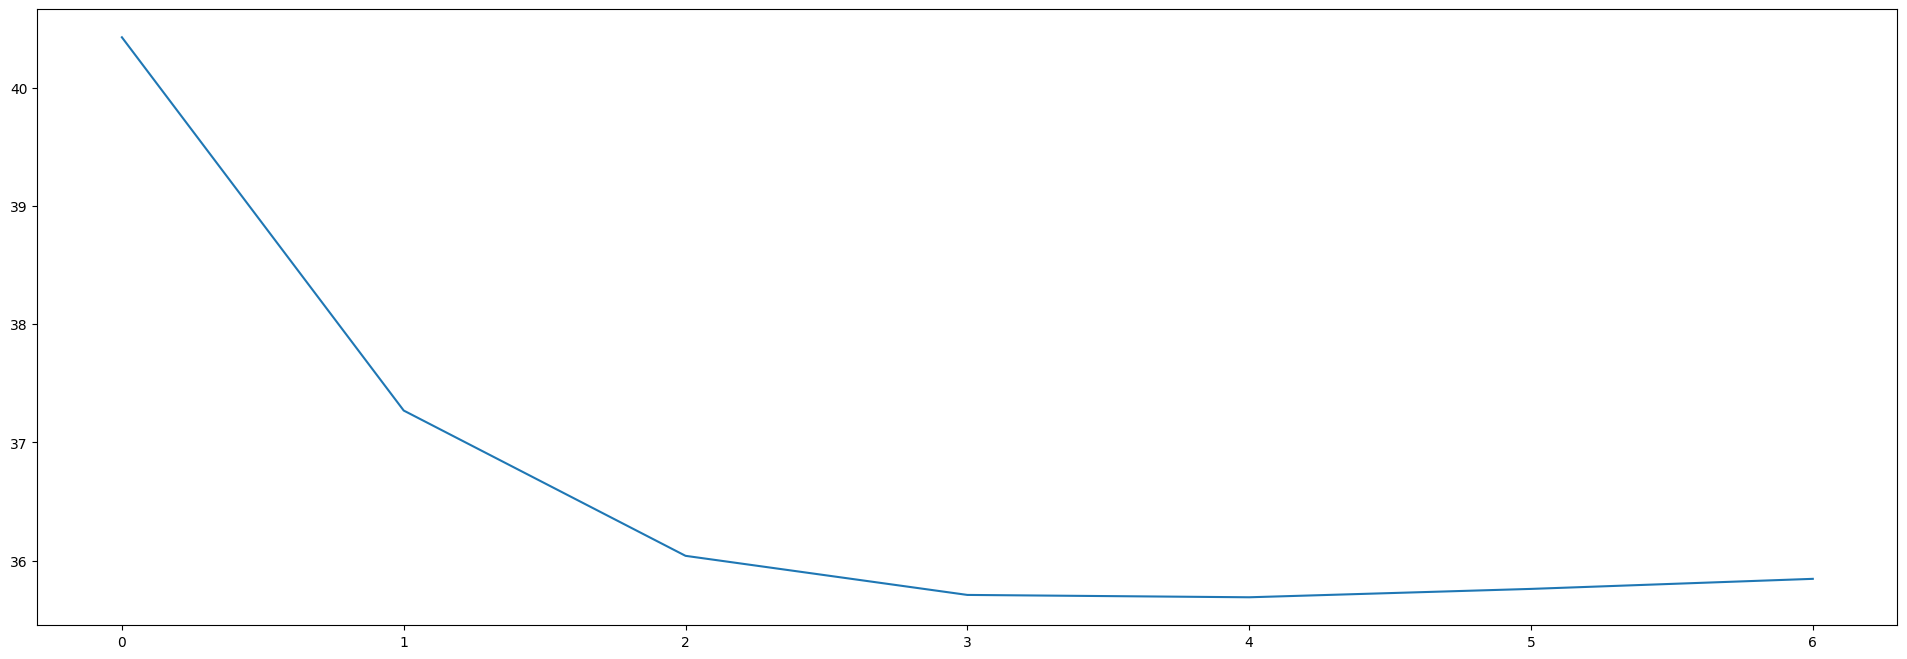

In [23]:
plt.figure(figsize=(24, 8))
plt.plot(range(len(future_30)), future_30)
print(future_30)

In [24]:
train_predicions=model2.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train.flatten()})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step


,Train Predictions,Actuals
0,44.407078,35.5
1,40.978680,29.0
2,39.699490,28.0
3,39.406853,35.5
4,39.419586,29.5
...,...,...
321995,35.335819,37.0
321996,35.292698,51.0
321997,35.341206,56.0
321998,35.400448,56.5


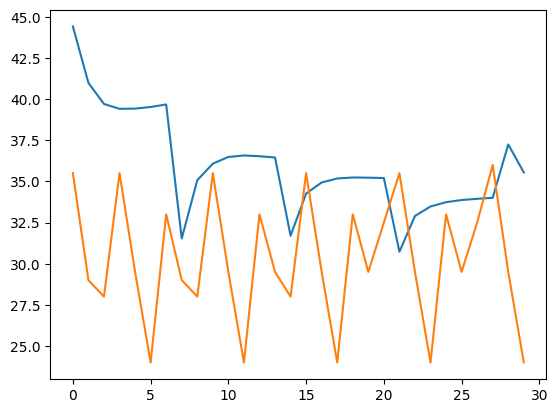

In [25]:
plt.plot(train_results["Train Predictions"][:30])
plt.plot(train_results["Actuals"][:30])


In [26]:
val_predicions=model2.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val.flatten()})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


,Validation Predictions,Actuals
0,29.120623,30.0
1,32.290066,37.0
2,33.198269,51.0
3,33.580891,56.0
4,33.754597,56.5
...,...,...
36045,38.415718,32.0
36046,38.527321,38.0
36047,38.499397,38.5
36048,38.397583,28.0


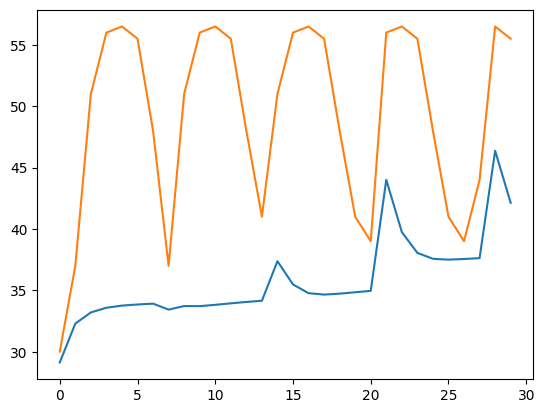

In [27]:
plt.plot(val_results["Validation Predictions"][:30])
plt.plot(val_results["Actuals"][:30])

In [28]:
test_predictions=model2.predict(X_test).flatten()
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test.flatten()})
test_results


159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


,Test Predictions,Actuals
0,36.804096,34.0
1,37.674984,32.0
2,37.865910,38.0
3,37.969997,38.5
4,37.944885,28.0
...,...,...
35401,35.483006,11.0
35402,35.535545,21.0
35403,35.573071,23.5
35404,35.596386,32.0


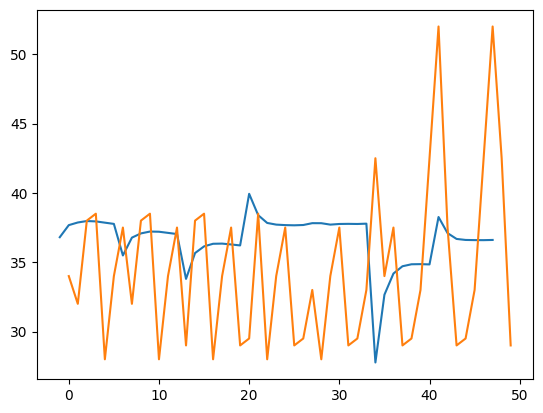

In [29]:

plt.plot(range(-1, -1+len(test_results["Test Predictions"][:49])),test_results["Test Predictions"][:49])
plt.plot(test_results["Actuals"][:50])
